In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

INPUT = Path("/kaggle/input")
print("Attached datasets:", [d.name for d in sorted(INPUT.iterdir())])

hits = list(INPUT.glob("**/train_images.npy"))
assert hits, "train_images.npy not found - is the tensors dataset attached?"
TENSORS = hits[0].parent

src_hits = list(INPUT.glob("**/src/localise.py"))
assert src_hits, ("src/localise.py not found - attach the src dataset. The "
                  "folder must be named 'src' for the relative imports to work.")
SRC_PARENT = src_hits[0].parent.parent
sys.path.insert(0, str(SRC_PARENT))

from src import config
from src.localise import (build_unet, bce_dice_loss, dice_coefficient,
                          hard_iou, _augment_pair, mask_to_box, box_iou)

OUT = Path("/kaggle/working")
config.set_seeds(config.SEED)

gpu = tf.config.list_physical_devices("GPU")
assert gpu, "No GPU - set Accelerator to GPU T4 x2 in Session options"

print(f"TENSORS  = {TENSORS}")
print(f"SRC path = {SRC_PARENT}")
print(f"GPU      = {gpu}")
print(f"canvas {config.LOC_INPUT_H}x{config.LOC_INPUT_W} | seed {config.SEED}")

Attached datasets: ['datasets']
TENSORS  = /kaggle/input/datasets/tataruteodor/localiser-tensors
SRC path = /kaggle/input/datasets/tataruteodor/ddsm-src
GPU      = [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
canvas 1024x576 | seed 28


I0000 00:00:1788770233.185175      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788770233.188440      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
BATCH = 4

def make_ds(split, batch=BATCH, shuffle=False, augment=False):
    """Datasets straight from the precomputed letterboxed tensors.

    No DICOM decode and no tf.data cache - the arrays are already the exact
    model inputs, verified against re-decoded DICOMs to within 2.4e-4.
    """
    imgs = np.load(TENSORS / f"{split}_images.npy")
    msks = np.load(TENSORS / f"{split}_masks.npy")
    scale = 255.0 if imgs.dtype == np.uint8 else 1.0
    print(f"{split}: {len(imgs)} pairs | {imgs.dtype} | {imgs.nbytes/1e6:.0f} MB "
          f"| mean fg {msks.mean():.5f}")
    ds = tf.data.Dataset.from_tensor_slices((imgs, msks)).map(
        lambda i, m: (tf.cast(i, tf.float32)[..., None] / scale,
                      tf.cast(m, tf.float32)[..., None]),
        num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(len(imgs), seed=config.SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch)
    if augment:
        ds = ds.map(_augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_ds("train", shuffle=True, augment=True)
val_ds   = make_ds("val")
test_ds  = make_ds("test")

i0, m0 = next(iter(train_ds))
print(f"\nbatch {i0.shape} range [{tf.reduce_min(i0):.3f}, {tf.reduce_max(i0):.3f}]"
      f" | fg {m0.numpy().mean():.5f}")
assert tf.reduce_max(i0) > 0.5, "images look wrong - check the dtype/scale"
assert 0.0001 < m0.numpy().mean() < 0.2, "masks look wrong - check the upload"

train: 1210 pairs | float16 | 1427 MB | mean fg 0.00471
val: 243 pairs | float16 | 287 MB | mean fg 0.00412
test: 243 pairs | float16 | 287 MB | mean fg 0.00443

batch (4, 1024, 576, 1) range [0.000, 1.000] | fg 0.00696


In [3]:
# Halves activation memory and uses T4 tensor cores. Must be set BEFORE
# build_unet - layer dtypes are fixed at construction. The output layer is
# already forced to float32 in build_unet, so the loss stays in full precision;
# at 0.34% foreground an fp16 sigmoid would underflow and Dice would collapse.
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("policy:", tf.keras.mixed_precision.global_policy().name)

model = build_unet()

opt = tf.keras.optimizers.Adam(1e-3)
LSO = (getattr(tf.keras.optimizers, "LossScaleOptimizer", None)
       or getattr(tf.keras.mixed_precision, "LossScaleOptimizer", None))
if LSO is not None and not isinstance(opt, LSO):
    opt = LSO(opt)

model.compile(optimizer=opt, loss=bce_dice_loss,
              metrics=[dice_coefficient, hard_iou])

bias = float(model.get_layer("lesion_prob").get_weights()[1][0])
print(f"{model.count_params():,} params")
print(f"output dtype = {model.output.dtype}   (must be float32)")
print(f"output bias  = {bias:.3f}   (prior init should be about -5.68)")
assert bias < -4.0, "output bias not prior-initialised - update build_unet"
assert model.output.dtype == tf.float32, "output must stay float32 under fp16"

policy: mixed_float16
7,768,353 params
output dtype = float32   (must be float32)
output bias  = -5.681   (prior init should be about -5.68)


In [4]:
EPOCHS = 100        # 2 for the smoke test; set to 100 before Save & Run All

cbs = [
    # start_from_epoch: BN moving averages are badly estimated for the first
    # few hundred steps at batch 4, so early val_hard_iou is not a signal.
    # Without this, a lucky epoch-1 peak can trigger a stop at ~epoch 16 and
    # restore near-random weights - a false negative on the W20 gate.
    tf.keras.callbacks.EarlyStopping(monitor="val_hard_iou", mode="max",
                                     patience=20, start_from_epoch=20,
                                     restore_best_weights=True, verbose=1),
    # LR schedule follows val_loss, which is moving monotonically (0.528 ->
    # 0.505), rather than val_hard_iou, which is still wandering. Cutting the
    # LR on a noisy metric at epoch 7 would just slow convergence.
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min",
                                         factor=0.5, patience=8, min_lr=1e-6,
                                         verbose=1),
    tf.keras.callbacks.ModelCheckpoint(str(OUT / "best.keras"),
                                       monitor="val_hard_iou", mode="max",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.CSVLogger(str(OUT / "history.csv")),
]

history = model.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS, callbacks=cbs, verbose=1)

Epoch 1/100


2026-09-07 08:38:08.131127: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 08:38:08.298998: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 08:38:09.422902: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 08:38:09.625809: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 08:38:11.513393: E external/local_xla/xla/service

302/303 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - dice_coefficient: 0.0745 - hard_iou: 0.0515 - loss: 0.4801

2026-09-07 08:41:15.913359: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 08:41:16.079428: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 08:41:16.822361: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 08:41:17.021538: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 08:41:18.530533: E external/local_xla/xla/service

303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - dice_coefficient: 0.0745 - hard_iou: 0.0516 - loss: 0.4801
Epoch 1: val_hard_iou improved from None to 0.00000, saving model to /kaggle/working/best.keras

Epoch 1: finished saving model to /kaggle/working/best.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 298s 531ms/step - dice_coefficient: 0.0909 - hard_iou: 0.0647 - loss: 0.4725 - val_dice_coefficient: 8.6096e-04 - val_hard_iou: 0.0000e+00 - val_loss: 0.5361 - learning_rate: 0.0010
Epoch 2/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - dice_coefficient: 0.1351 - hard_iou: 0.0922 - loss: 0.4519
Epoch 2: val_hard_iou did not improve from 0.00000
303/303 ━━━━━━━━━━━━━━━━━━━━ 76s 246ms/step - dice_coefficient: 0.1510 - hard_iou: 0.1023 - loss: 0.4444 - val_dice_coefficient: 0.0044 - val_hard_iou: 0.0000e+00 - val_loss: 0.5177 - learning_rate: 0.0010
Epoch 3/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - dice_coefficient: 0.1761 - hard_iou: 0.1193 - loss: 0.4322
Epoch 3: val_hard_iou improved from 0.

{
  "device": "{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}",
  "lr": 0.001,
  "batch_size": 4,
  "epochs_requested": 100,
  "epochs_run": 88,
  "seed": 28,
  "input": [
    1024,
    576
  ],
  "depth": 4,
  "base_filters": 32,
  "dice_bce_weights": [
    0.5,
    0.5
  ],
  "output_prior_bias": -5.6805739402771,
  "input_dtype": "float16",
  "best_val_hard_iou": 0.36492690443992615,
  "best_val_dice": 0.46361449360847473,
  "final_train_loss": 0.2629682719707489,
  "all_background_loss": 0.534,
  "precision": "mixed_float16"
}


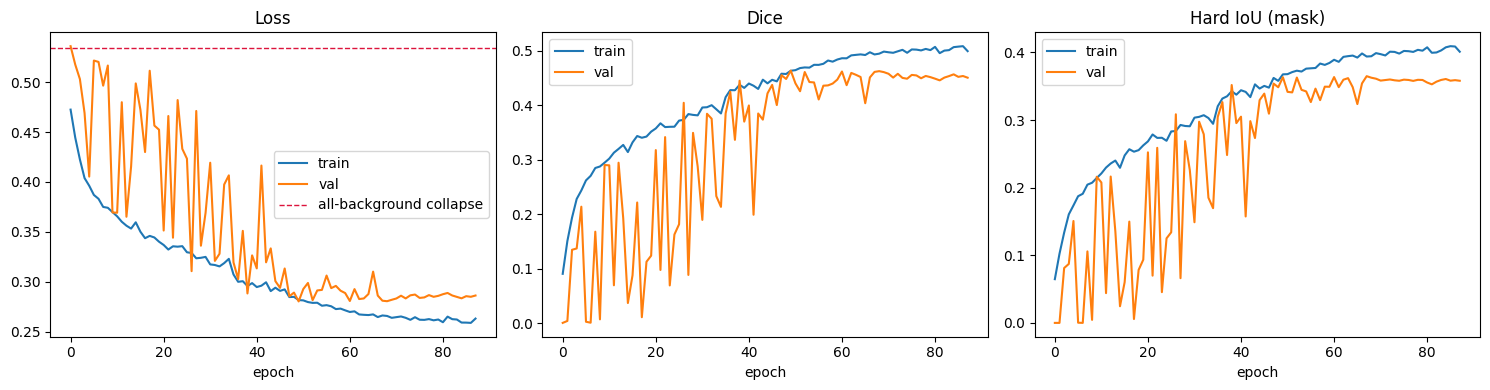

In [5]:
h = history.history
manifest = {
    "device": str(tf.config.experimental.get_device_details(gpu[0])),
    "lr": 1e-3, "batch_size": BATCH, "epochs_requested": EPOCHS,
    "epochs_run": len(h["loss"]), "seed": config.SEED,
    "input": [config.LOC_INPUT_H, config.LOC_INPUT_W],
    "depth": config.LOC_DEPTH, "base_filters": config.LOC_BASE_FILTERS,
    "dice_bce_weights": list(config.LOC_DICE_BCE_WEIGHTS),
    "output_prior_bias": bias,
    "input_dtype": str(np.load(TENSORS / "train_images.npy", mmap_mode="r").dtype),
    "best_val_hard_iou": float(max(h["val_hard_iou"])),
    "best_val_dice": float(max(h["val_dice_coefficient"])),
    "final_train_loss": float(h["loss"][-1]),
    "all_background_loss": 0.534,
    "precision": tf.keras.mixed_precision.global_policy().name,
}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ["loss", "dice_coefficient", "hard_iou"],
                          ["Loss", "Dice", "Hard IoU (mask)"]):
    ax.plot(h[key], label="train")
    ax.plot(h[f"val_{key}"], label="val")
    if key == "loss":
        ax.axhline(0.534, ls="--", c="crimson", lw=1,
                   label="all-background collapse")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout()
fig.savefig(OUT / "training_curves.png", dpi=150)
plt.show()

Detection rate (a box was produced): 79.7%
Box IoU  mean 0.351 | median 0.261
IoU >= 0.50: 45.3%   IoU >= 0.30: 50.0%

W20 GATE: mean box IoU >= 0.30 keeps the supervised localiser; below that, fall back to CAM-only.


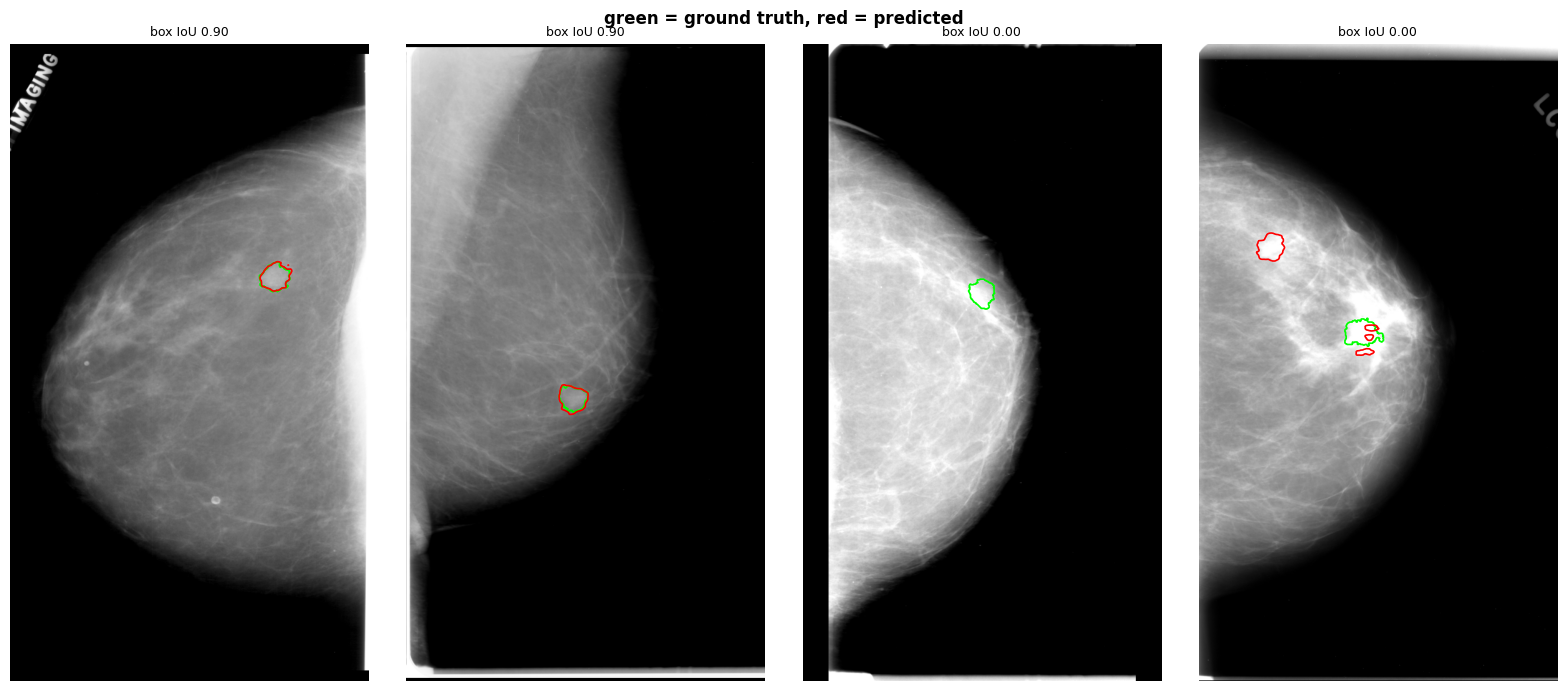

In [6]:
# hard_iou is MASK IoU. The gate is BOX IoU >= 0.30, which is what the crop
# pipeline consumes. They are not the same number.
imgs = np.load(TENSORS / "val_images.npy")
msks = np.load(TENSORS / "val_masks.npy")
scale = 255.0 if imgs.dtype == np.uint8 else 1.0

N = 64
probs = model.predict(imgs[:N].astype(np.float32)[..., None] / scale,
                      batch_size=BATCH, verbose=0)[..., 0]

rows = []
for i in range(N):
    gt = mask_to_box(msks[i].astype(np.float32), keep_largest=False)
    pr = mask_to_box(probs[i])
    rows.append({"i": i, "detected": pr is not None,
                 "box_iou": box_iou(gt, pr) if (gt and pr) else 0.0})
r = pd.DataFrame(rows)

print(f"Detection rate (a box was produced): {r['detected'].mean():.1%}")
print(f"Box IoU  mean {r['box_iou'].mean():.3f} | median {r['box_iou'].median():.3f}")
print(f"IoU >= 0.50: {(r['box_iou'] >= 0.5).mean():.1%}   "
      f"IoU >= 0.30: {(r['box_iou'] >= 0.3).mean():.1%}")
print(f"\nW20 GATE: mean box IoU >= 0.30 keeps the supervised localiser; "
      f"below that, fall back to CAM-only.")

best = r.sort_values("box_iou", ascending=False)
show = list(best["i"][:2]) + list(best["i"][-2:])
fig, axes = plt.subplots(1, 4, figsize=(16, 7))
for ax, i in zip(axes, show):
    ax.imshow(imgs[i].astype(np.float32) / scale, cmap="gray")
    ax.contour(msks[i], levels=[0.5], colors="lime", linewidths=1.2)
    ax.contour(probs[i], levels=[0.5], colors="red", linewidths=1.2)
    ax.set_title(f"box IoU {r.loc[i,'box_iou']:.2f}", fontsize=9)
    ax.axis("off")
plt.suptitle("green = ground truth, red = predicted", fontweight="bold")
plt.tight_layout()
fig.savefig(OUT / "prediction_examples.png", dpi=150)
plt.show()